# Modeling Pipeline – Job Ranking System

## 1. Exploratory Data Analysis (EDA)
The dataset is analyzed to understand the relationship between candidates (CVs) and job descriptions.  
Each CV is associated with multiple job postings, and the objective is to **rank jobs per CV** according to relevance.  
The target variable is binary (relevant / not relevant) and serves as supervision for learning the ranking signal.

---

## 2. Data Preprocessing and Group-Based Splitting
Feature engineering is performed to capture skill matching, missing skills, and domain information.  
To prevent data leakage and ensure realistic evaluation, data is split **at the CV level** using group-based splitting
(`GroupShuffleSplit`), ensuring that all job postings associated with a given CV appear in the same split.

---

## 3. Pointwise Learning-to-Rank with Logistic Regression (Baseline)
The ranking task is modeled using a **pointwise learning-to-rank approach**, where a scoring function is learned for
each (CV, Job) pair:

(CV, Job) → relevance score

As a baseline, **Logistic Regression** is used to predict the probability of relevance.  
This probability is treated as a **continuous relevance score**, which is then used to rank jobs per CV.

The model is trained using **log loss (binary cross-entropy)** as a **surrogate objective**, providing a simple,
interpretable, and stable baseline for ranking.

---

## 4. Ranking-Based Evaluation
Predicted relevance scores are used to generate ranked job lists **per CV**.  
Ranking quality is evaluated using metrics designed for recommendation systems:
- **Mean Reciprocal Rank (MRR)**
- **Precision@K**

These metrics directly reflect how early relevant jobs appear in the ranked lists and align with the final
recommendation objective.

---

## 5. Learning Curve and Bias–Variance Analysis
Learning curves are constructed by training the model on increasing fractions of CVs and evaluating ranking
performance using MRR.  
This analysis is used to study generalization behavior and to determine whether performance is limited by
training data size or by feature expressiveness.

---

## 6. Model Comparison
More expressive scoring models are evaluated under the same ranking framework and compared against the
Logistic Regression baseline.  
Results indicate that learning a continuous relevance score is more appropriate for ranking than treating
the task as a pure classification problem.

---

## 7. Conclusion
The task is inherently a **ranking problem**, where the goal is to order job descriptions per candidate rather
than predict independent class labels.  
A pointwise scoring-based approach with Logistic Regression provides a strong and interpretable baseline,
while ranking-aware evaluation metrics (MRR and Precision@K) ensure alignment with the recommendation objective.

---

## Future Work
Future extensions may explore **pairwise** or **listwise learning-to-rank objectives**
(e.g., RankSVM or LambdaMART) to directly optimize ranking quality and better capture relative relevance signals.


In [2]:
!pip install scikit-optimize
!pip install skopt
!pip install --upgrade pip
!pip install scikit-optimize
!pip install xgboost

ERROR: Could not find a version that satisfies the requirement skopt (from versions: none)
ERROR: No matching distribution found for skopt


  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Zakaria\anaconda3\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
from sklearn.preprocessing import PolynomialFeatures,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from imblearn.under_sampling import RandomUnderSampler

## Read dataset

In [5]:
df = pd.read_csv(r"C:\Users\Zakaria\Downloads\machine_learning_finalproject\final_df_bgd_bgd_bgd_top30.csv")
df.head(319)

,cv_id,jd_id,matched_weight,required_weight,match_ratio,missing_required_skills_count,missing_hard_skills,missing_soft_skills,required_hard_skills,required_soft_skills,...,feat_68,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8
0,1,1,1,1,1.000000,0,[],['adaptability'],['ai'],"['teamwork', 'leadership', 'customer focus', '...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
1,1,2,3,4,0.750000,1,['systems engineering'],"['communication', 'problem solving']","['ai', 'systems engineering', 'financial analy...","['communication', 'problem solving']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
2,1,3,1,3,0.333333,2,"['marketing', 'microsoft office']",[],"['ai', 'marketing', 'microsoft office']","['teamwork', 'leadership', 'growth mindset']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
3,1,4,1,3,0.333333,2,"['sales', 'product management']","['problem solving', 'time management', 'work e...","['ai', 'sales', 'product management']","['problem solving', 'leadership', 'time manage...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
4,1,5,5,8,0.625000,3,"['networking', 'sales', 'product management']","['problem solving', 'adaptability', 'attention...","['ai', 'models', 'reporting', 'networking', 's...","['teamwork', 'problem solving', 'leadership', ...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,315,2,5,0.400000,3,"['sales', 'marketing', 'product management']","['problem solving', 'adaptability', 'attention...","['ai', 'sales', 'marketing', 'product manageme...","['teamwork', 'problem solving', 'leadership', ...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
315,1,316,3,6,0.500000,3,"['sales', 'marketing', 'product management']","['time management', 'adaptability', 'attention...","['ai', 'reporting', 'sales', 'marketing', 'pro...","['leadership', 'time management', 'customer fo...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
316,1,317,2,3,0.666667,1,['sales'],['communication'],"['ai', 'sales', 'recruitment']","['communication', 'teamwork', 'leadership', 'c...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
317,1,318,3,6,0.500000,3,"['sales', 'product management', 'microsoft off...","['communication', 'attention to detail']","['ai', 'sales', 'product management', 'project...","['communication', 'teamwork', 'customer focus'...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967


In [339]:
df.columns

Index(['cv_id', 'jd_id', 'matched_weight', 'required_weight', 'match_ratio',
       'missing_required_skills_count', 'missing_hard_skills',
       'missing_soft_skills', 'required_hard_skills', 'required_soft_skills',
       'required_skill_count', 'soft_skill_match_score',
       'missing_soft_skills_new', 'missing_soft_skills_count_new', 'domain',
       'final_score', 'target', 'video_id', 'feat_95', 'feat_69', 'feat_125',
       'feat_20', 'feat_91', 'feat_68', 'feat_117', 'feat_76', 'feat_11',
       'feat_88', 'feat_94', 'feat_27', 'feat_82', 'feat_78', 'feat_8'],
      dtype='object')

In [343]:
df.shape

(10176, 33)

In [347]:
print(f" number cvs : {df['cv_id'].nunique()}, number jd: {df['jd_id'].nunique()}")

 number cvs : 32, number jd: 318


In [335]:
df['target'].value_counts()

target
0    7809
1    2367
Name: count, dtype: int64

In [430]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10176 entries, 0 to 10175
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cv_id                          10176 non-null  int64  
 1   jd_id                          10176 non-null  int64  
 2   matched_weight                 10176 non-null  int64  
 3   required_weight                10176 non-null  int64  
 4   match_ratio                    10176 non-null  float64
 5   missing_required_skills_count  10176 non-null  int64  
 6   missing_hard_skills            10176 non-null  object 
 7   missing_soft_skills            10176 non-null  object 
 8   required_hard_skills           10176 non-null  object 
 9   required_soft_skills           10176 non-null  object 
 10  required_skill_count           10176 non-null  int64  
 11  soft_skill_match_score         10176 non-null  float64
 12  missing_soft_skills_new        10176 non-null 

In [516]:
selected_cols = [
    'matched_weight',
    'required_weight',
    'required_skill_count',
    'missing_required_skills_count',
    'match_ratio',
    'missing_soft_skills_count_new',
    'domain',
    'feat_95', 'feat_69', 'feat_125',
    'feat_20', 'feat_91', 'feat_68',
    'feat_117', 'feat_76', 'feat_11',
    'feat_88', 'feat_94', 'feat_27',
    'feat_82', 'feat_78', 'feat_8',
    'target'
]

df_model = df[selected_cols].copy()

df_model = df_model.rename(
    columns={'match_ratio': 'hard_skill_match_ratio'}
)

df_model.head(30)

,matched_weight,required_weight,required_skill_count,missing_required_skills_count,hard_skill_match_ratio,missing_soft_skills_count_new,domain,feat_95,feat_69,feat_125,...,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8,target
0,1,1,5,0,1.000000,0,Support,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
1,3,4,6,1,0.750000,1,IT,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
2,1,3,6,2,0.333333,0,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
3,1,3,9,2,0.333333,1,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
4,5,8,18,3,0.625000,2,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
5,5,11,18,6,0.454545,1,Finance,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
6,5,8,19,3,0.625000,3,Engineering,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
7,3,7,18,4,0.428571,2,Finance,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
8,1,3,6,2,0.333333,0,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
9,4,8,18,4,0.500000,1,Administrative,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1


# Encode Domain

In [519]:
len(df_model['domain'].unique())

13

In [521]:
df_model['domain'].value_counts()

domain
IT                2240
Engineering       2080
Business          1504
Finance           1248
HR                1184
Support            576
Administrative     416
Research           256
Management         192
Operations         160
Analytics          128
Creative            96
Consulting          96
Name: count, dtype: int64

In [523]:
df_model_encoded = pd.get_dummies(
    df_model,
    columns=['domain'],
    prefix='domain'
)
bool_cols = df_model_encoded.select_dtypes(include='bool').columns
df_model_encoded[bool_cols] = df_model_encoded[bool_cols].astype(int)

In [525]:
df_model_encoded.head(32)

,matched_weight,required_weight,required_skill_count,missing_required_skills_count,hard_skill_match_ratio,missing_soft_skills_count_new,feat_95,feat_69,feat_125,feat_20,...,domain_Consulting,domain_Creative,domain_Engineering,domain_Finance,domain_HR,domain_IT,domain_Management,domain_Operations,domain_Research,domain_Support
0,1,1,5,0,1.000000,0,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,0,0,0,0,0,0,1
1,3,4,6,1,0.750000,1,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,0,0,1,0,0,0,0
2,1,3,6,2,0.333333,0,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,0,0,0,0,0,0,0
3,1,3,9,2,0.333333,1,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,0,0,0,0,0,0,0
4,5,8,18,3,0.625000,2,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,0,0,0,0,0,0,0
5,5,11,18,6,0.454545,1,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,1,0,0,0,0,0,0
6,5,8,19,3,0.625000,3,-1.322632,1.406155,-2.846429,1.291473,...,0,0,1,0,0,0,0,0,0,0
7,3,7,18,4,0.428571,2,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,1,0,0,0,0,0,0
8,1,3,6,2,0.333333,0,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,0,0,0,0,0,0,0
9,4,8,18,4,0.500000,1,-1.322632,1.406155,-2.846429,1.291473,...,0,0,0,0,0,0,0,0,0,0


In [527]:
df_model_encoded.describe()

,matched_weight,required_weight,required_skill_count,missing_required_skills_count,hard_skill_match_ratio,missing_soft_skills_count_new,feat_95,feat_69,feat_125,feat_20,...,domain_Consulting,domain_Creative,domain_Engineering,domain_Finance,domain_HR,domain_IT,domain_Management,domain_Operations,domain_Research,domain_Support
count,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,...,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000
mean,2.697229,8.056604,14.930818,5.359375,0.355347,2.589524,-0.488710,0.562177,-2.982411,0.989733,...,0.009434,0.009434,0.204403,0.122642,0.116352,0.220126,0.018868,0.015723,0.025157,0.056604
std,1.854569,3.711876,5.594656,3.169213,0.211519,3.106187,1.361514,1.374077,1.964801,1.925915,...,0.096674,0.096674,0.403284,0.328041,0.320663,0.414352,0.136065,0.124409,0.156610,0.231095
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.268386,-1.553395,-7.444741,-4.796014,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,5.000000,11.000000,3.000000,0.200000,0.000000,-1.334173,-0.295707,-4.275203,0.297454,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,8.000000,15.000000,5.000000,0.333333,1.000000,-0.493819,0.361695,-3.095893,1.499649,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,11.000000,19.000000,7.000000,0.500000,5.000000,0.251136,1.414726,-1.154551,2.252898,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,12.000000,19.000000,29.000000,19.000000,1.000000,12.000000,2.660940,4.294547,0.085521,3.823320,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [529]:
df_model_encoded.columns

Index(['matched_weight', 'required_weight', 'required_skill_count',
       'missing_required_skills_count', 'hard_skill_match_ratio',
       'missing_soft_skills_count_new', 'feat_95', 'feat_69', 'feat_125',
       'feat_20', 'feat_91', 'feat_68', 'feat_117', 'feat_76', 'feat_11',
       'feat_88', 'feat_94', 'feat_27', 'feat_82', 'feat_78', 'feat_8',
       'target', 'domain_Administrative', 'domain_Analytics',
       'domain_Business', 'domain_Consulting', 'domain_Creative',
       'domain_Engineering', 'domain_Finance', 'domain_HR', 'domain_IT',
       'domain_Management', 'domain_Operations', 'domain_Research',
       'domain_Support'],
      dtype='object')

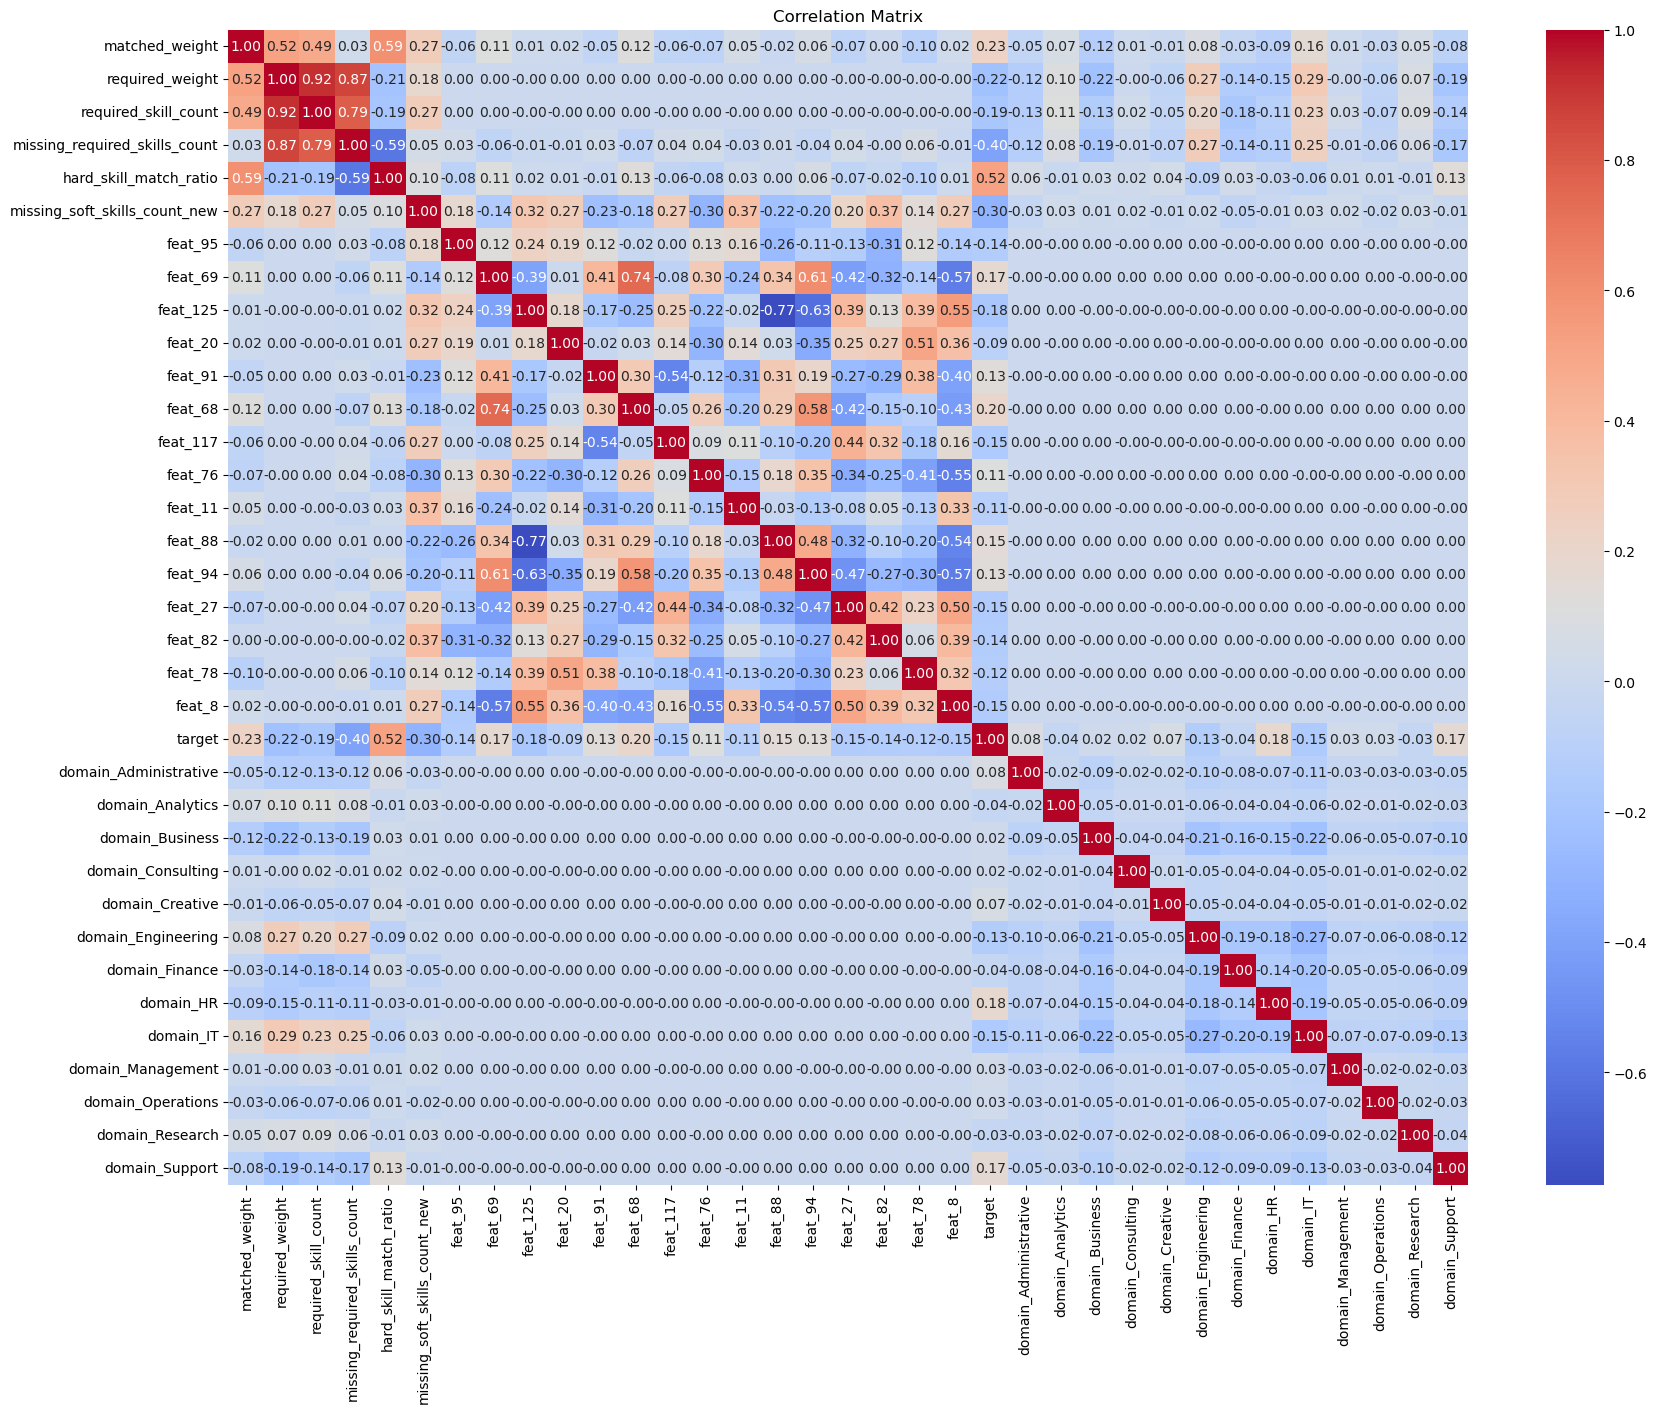

In [531]:
correlation_matrix = df_model_encoded.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

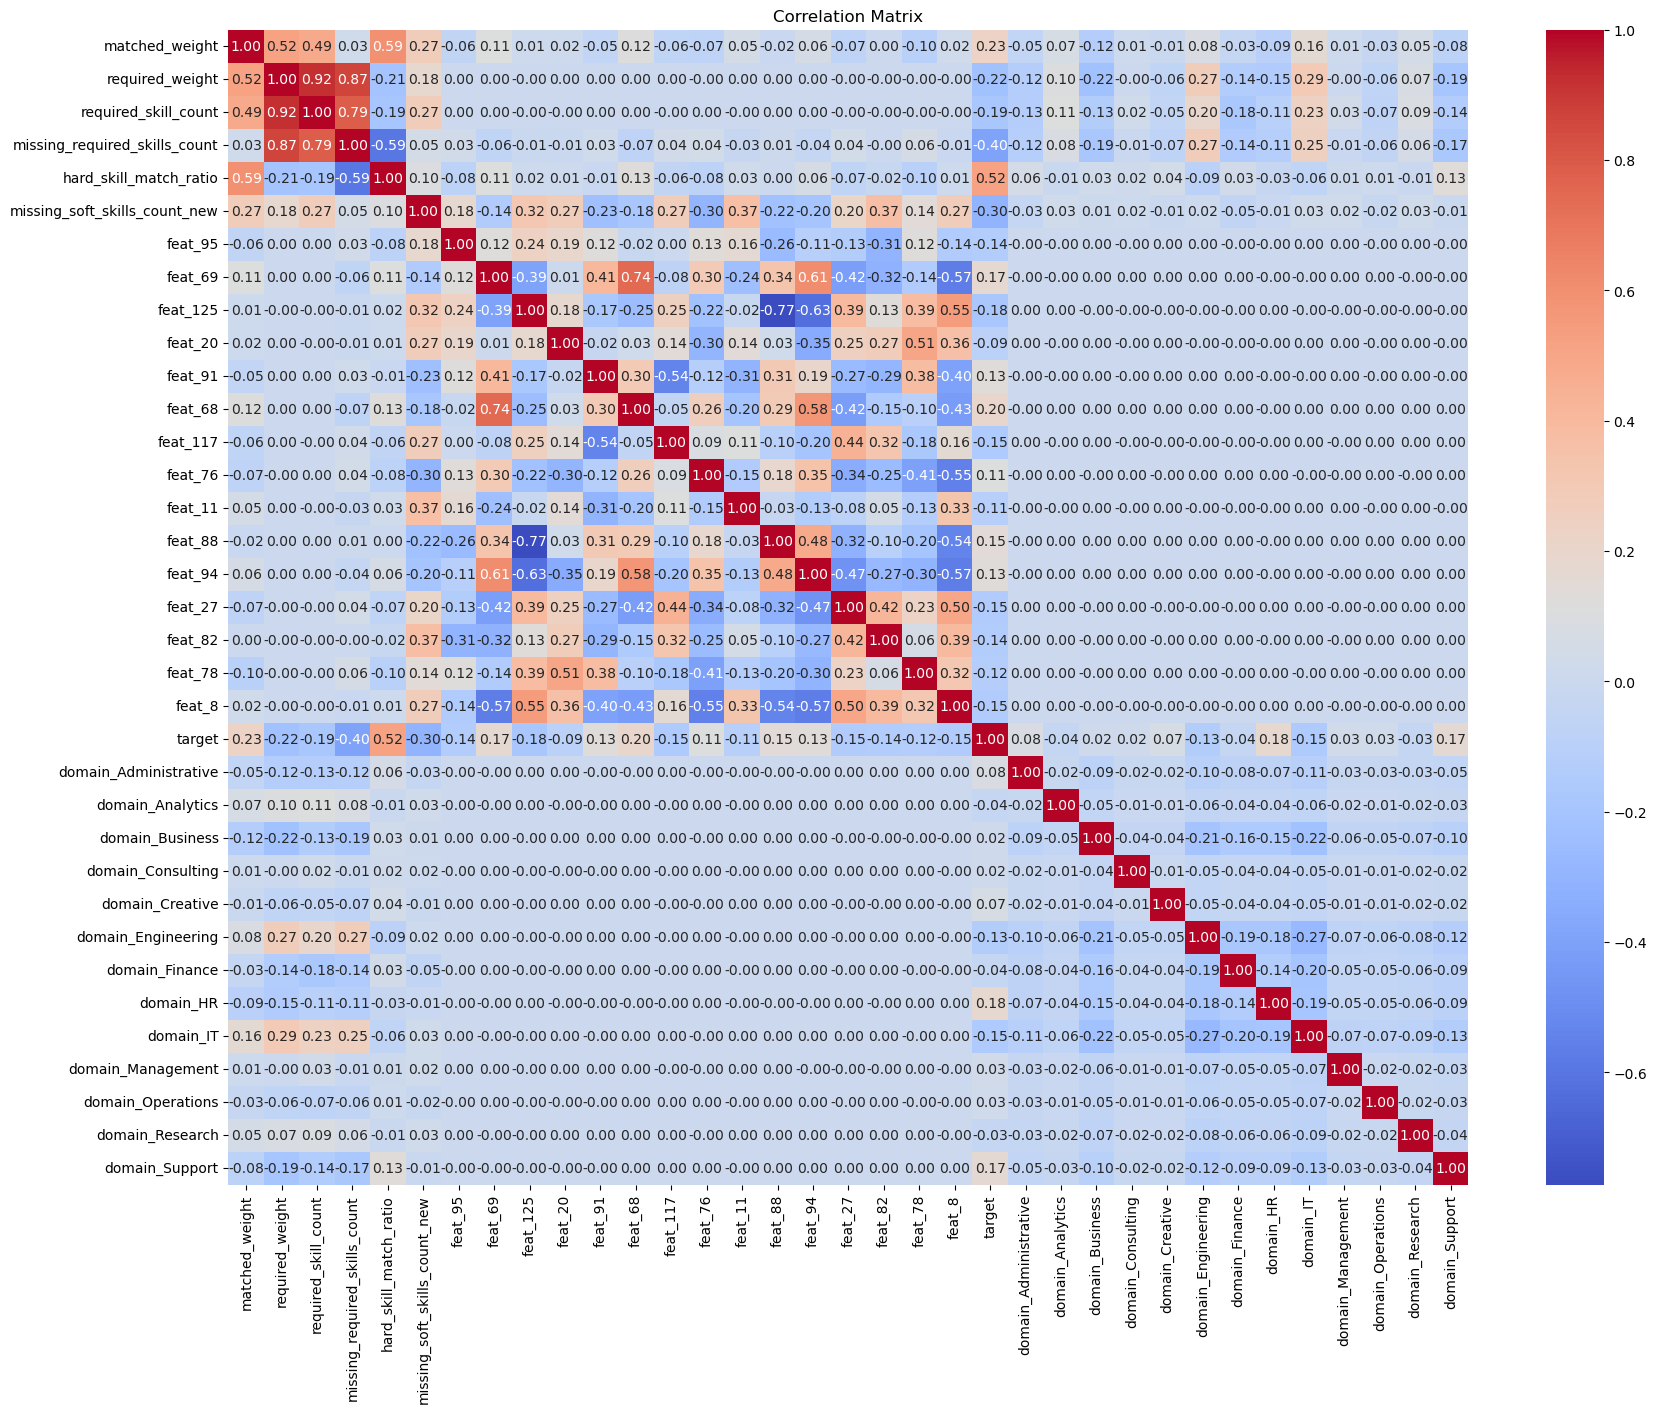

In [532]:
correlation_matrix = df_model_encoded.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [533]:
df_model_encoded.corr(numeric_only=True)['target'].sort_values(ascending=False)

target                           1.000000
hard_skill_match_ratio           0.516234
matched_weight                   0.227853
feat_68                          0.196112
domain_HR                        0.182506
feat_69                          0.173417
domain_Support                   0.168112
feat_88                          0.146128
feat_94                          0.130470
feat_91                          0.129583
feat_76                          0.109968
domain_Administrative            0.080153
domain_Creative                  0.071389
domain_Management                0.031352
domain_Operations                0.027640
domain_Business                  0.023044
domain_Consulting                0.020860
domain_Research                 -0.032003
domain_Analytics                -0.035008
domain_Finance                  -0.037789
feat_20                         -0.087494
feat_11                         -0.110603
feat_78                         -0.123329
domain_Engineering              -0

## Correlation analysis shows that hard skill match ratio is the strongest predictor of job relevance, followed by soft skill match score. Missing required skills exhibit strong negative correlation with the relevance label, confirming their importance. Domain features act as contextual signals rather than primary decision factors.

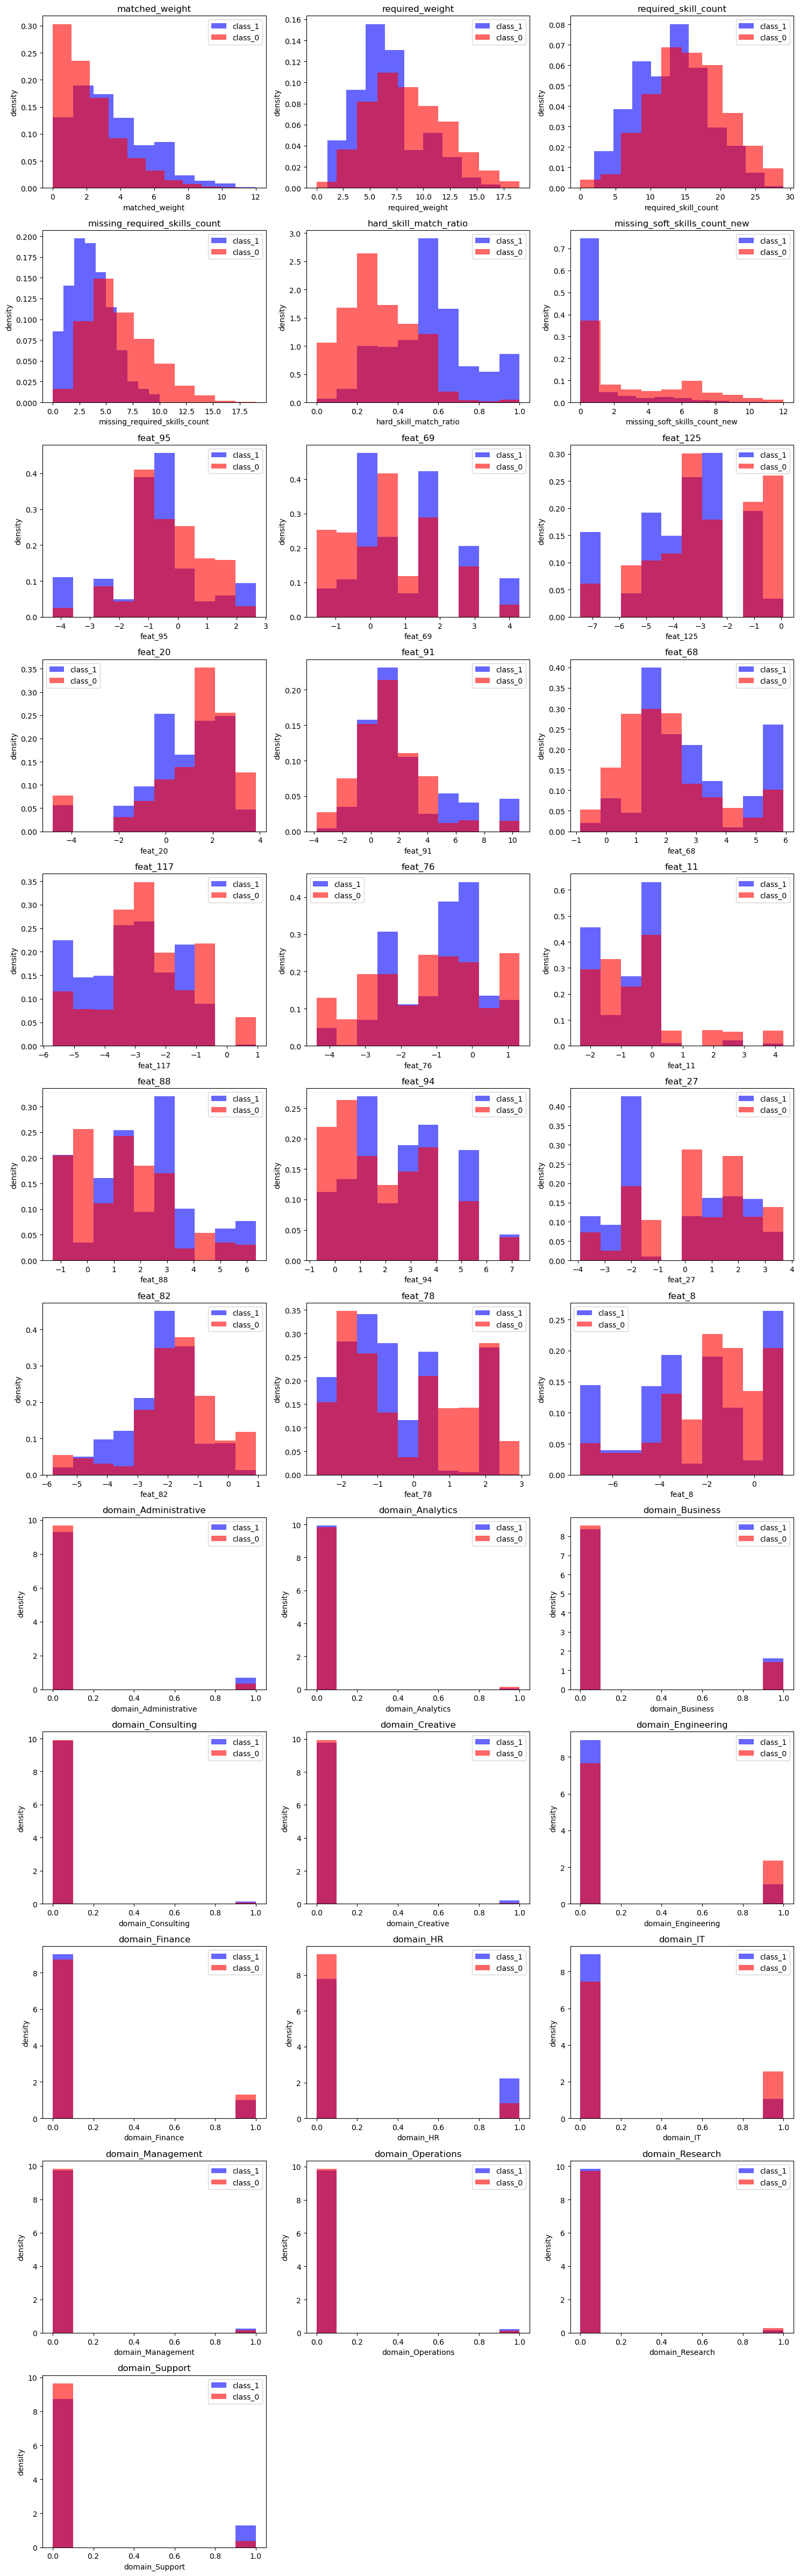

In [535]:
import math

cols = df_model_encoded.columns.drop('target')
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(cols):
    axes[i].hist(
        df_model_encoded[df_model_encoded['target'] == 1][feature],
        color='blue',
        alpha=0.6,
        density=True,
        label='class_1'
    )
    axes[i].hist(
        df_model_encoded[df_model_encoded['target'] == 0][feature],
        color='red',
        alpha=0.6,
        density=True,
        label='class_0'
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('density')
    axes[i].legend()


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
plt.show()

#### This code performs a group-aware Train/Validation/Test split.
#### Each CV is treated as a group to prevent information leakage.
#### The split ensures that all job descriptions related to the same CV
#### appear in only one split (train, validation, or test).


##### GroupShuffleSplit performs splitting based on CV IDs (groups),
##### ensuring that all rows belonging to the same CV stay in the same split.

In [539]:
test_idx

array([   0,    1,    2, ..., 3495, 3496, 3497], dtype=int64)

In [540]:
print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))

Train rows: 6360
Test rows: 1908


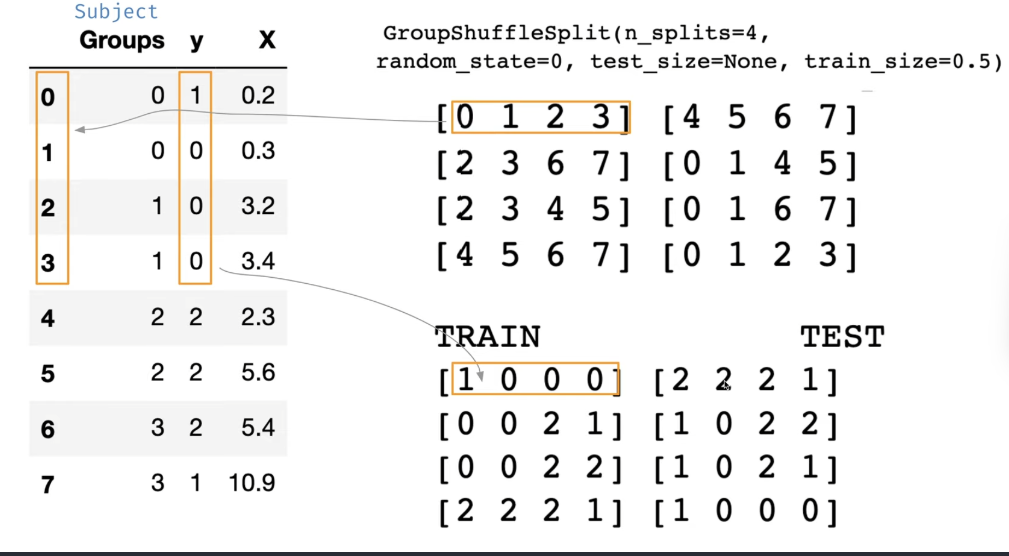

In [542]:
X = df_model_encoded.drop(columns=['target'])
y = df_model_encoded['target']
groups = df['cv_id']
groups.unique() # 15 cv (group)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
      dtype=int64)

In [543]:
gss1 = GroupShuffleSplit(
    test_size=0.35,
    n_splits=1,
    random_state=1000
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
cv_train = groups.iloc[train_idx]

X_ = X.iloc[temp_idx]
y_ = y.iloc[temp_idx]
cv_ = groups.iloc[temp_idx]

In [544]:
gss2 = GroupShuffleSplit(
    test_size=0.5,
    n_splits=1,
    random_state=2024
)

test_idx, val_idx = next(
    gss2.split(X_, y_, groups=cv_)
)

X_test = X_.iloc[test_idx]
y_test = y_.iloc[test_idx]
cv_test = cv_.iloc[test_idx]

X_val = X_.iloc[val_idx]
y_val = y_.iloc[val_idx]
cv_val = cv_.iloc[val_idx]

In [545]:
print(f"train: {X_train.shape[0]}")
print(f"validation: {X_val.shape[0]}")
print(f"test: {X_test.shape[0]}")
print("-"*50)
print(set(cv_train).intersection(set(cv_val)))
print(set(cv_train).intersection(set(cv_test)))
print(set(cv_val).intersection(set(cv_test)))

train: 6360
validation: 1908
test: 1908
--------------------------------------------------
set()
set()
set()


### no CV leakage (set(), set(), set())

In [547]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [548]:
val_scores = model.predict_proba(X_val)[:, 1]

val_rank_df = X_val.copy()
val_rank_df['cv_id'] = cv_val.values
val_rank_df['score'] = val_scores
val_rank_df['target'] = y_val.values

val_rank_df = val_rank_df.sort_values(
by = ['cv_id','score'],
ascending = [True,False]
)

val_rank_df[['cv_id','score']].head(318)

,cv_id,score
1617,6,9.999505e-01
1676,6,9.999200e-01
1590,6,9.997567e-01
1854,6,9.997164e-01
1644,6,9.996818e-01
...,...,...
1828,6,2.697461e-05
1773,6,2.015364e-05
1699,6,1.177783e-05
1783,6,6.059937e-06


In [549]:
def rank(X,y1,cv,model):
    X_scores = model.predict_proba(X)[:, 1]
    X_rank_df = X.copy()
    X_rank_df['cv_id'] = cv.values
    X_rank_df['score'] = X_scores
    X_rank_df['target'] = y1.values
    X_rank_df = X_rank_df.sort_values(
    by=['cv_id', 'score'],
    ascending=[True, False]
    )
    return X_rank_df

In [550]:
df.iloc[1617].to_dict()

{'cv_id': 6,
 'jd_id': 28,
 'matched_weight': 2,
 'required_weight': 2,
 'match_ratio': 1.0,
 'missing_required_skills_count': 0,
 'missing_hard_skills': '[]',
 'missing_soft_skills': "['problem solving', 'time management', 'collaboration']",
 'required_hard_skills': "['ai', 'systems engineering']",
 'required_soft_skills': "['problem solving', 'time management', 'customer focus', 'organizational skills', 'collaboration']",
 'required_skill_count': 7,
 'soft_skill_match_score': 0.935915963095171,
 'missing_soft_skills_new': '[]',
 'missing_soft_skills_count_new': 0,
 'domain': 'Support',
 'final_score': 0.9551411741666196,
 'target': 1,
 'video_id': 6,
 'feat_95': -2.840510368347168,
 'feat_69': -0.4627630710601806,
 'feat_125': -7.444740772247314,
 'feat_20': -2.1214194297790527,
 'feat_91': 1.138327717781067,
 'feat_68': -0.1696105748414993,
 'feat_117': -2.705371618270874,
 'feat_76': -0.2254900783300399,
 'feat_11': -2.111980676651001,
 'feat_88': 5.063787937164307,
 'feat_94': 3.3

In [551]:
val_rank_df[val_rank_df['cv_id'] == 14][['cv_id','score','target']].head(10)

,cv_id,score,target


In [552]:
val_rank_df[val_rank_df['cv_id'] == 14][['cv_id','score','target']].tail(10)

,cv_id,score,target


In [553]:
df.iloc[4134].to_dict()

{'cv_id': 14,
 'jd_id': 1,
 'matched_weight': 0,
 'required_weight': 1,
 'match_ratio': 0.0,
 'missing_required_skills_count': 1,
 'missing_hard_skills': "['ai']",
 'missing_soft_skills': "['adaptability']",
 'required_hard_skills': "['ai']",
 'required_soft_skills': "['teamwork', 'leadership', 'customer focus', 'adaptability']",
 'required_skill_count': 5,
 'soft_skill_match_score': 0.389919648291191,
 'missing_soft_skills_new': "['teamwork', 'leadership', 'customer focus', 'adaptability']",
 'missing_soft_skills_count_new': 4,
 'domain': 'Support',
 'final_score': 0.2729437538038337,
 'target': 0,
 'video_id': 14,
 'feat_95': 1.5066580772399902,
 'feat_69': 0.4071976244449615,
 'feat_125': -5.307971477508545,
 'feat_20': 3.823319673538208,
 'feat_91': -3.8212249279022217,
 'feat_68': 4.227786540985107,
 'feat_117': -1.0113533735275269,
 'feat_76': 0.5616553425788879,
 'feat_11': 4.269791126251221,
 'feat_88': 3.0653951168060303,
 'feat_94': 3.756204843521118,
 'feat_27': -0.935815155

# Evaluation Learn to Rank
## MRR (Mean Reciprocal Rank)
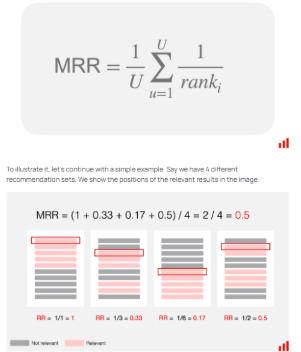

# Precision@k

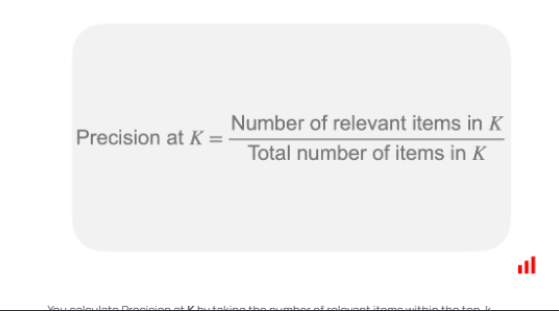

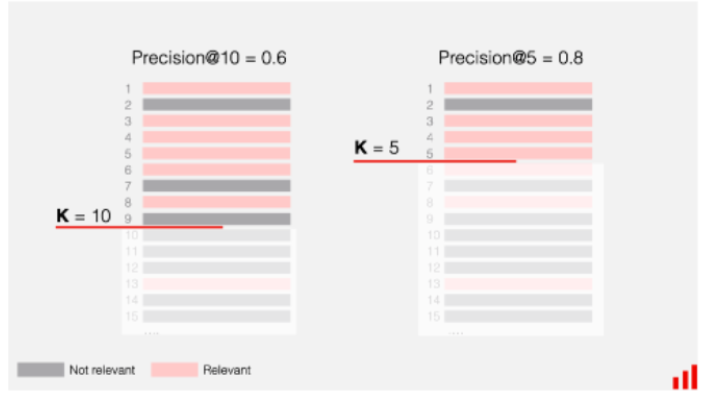

In [556]:
def mean_reciprocal_rank(df):
    rr = []
    for cv, group in df.groupby('cv_id'):
        group = group.reset_index(drop=True)
        relevant = group[group['target'] == 1]

        if len(relevant) == 0:
            continue

        first_rank = relevant.index[0] + 1
        rr.append(1 / first_rank)

    return sum(rr) / len(rr)

In [557]:
def precision_at_k(df, k):
    precisions = []
    for cv, group in df.groupby('cv_id'):
        top_k = group.head(k)
        precisions.append(top_k['target'].mean())


    return sum(precisions) / len(precisions)

In [558]:
mrr_val = mean_reciprocal_rank(val_rank_df)
print("MRR (Validation):", mrr_val)

MRR (Validation): 0.7129629629629629


In [559]:
mrr_v = mean_reciprocal_rank(rank(X_val,y_val,cv_val,model))
mrr_test = mean_reciprocal_rank(rank(X_test,y_test,cv_test,model))
mrr_train = mean_reciprocal_rank(rank(X_train,y_train,cv_train,model))

print(f"val {mrr_v}")
print(f"test {mrr_test}")
print(f"train {mrr_train}")

val 0.7129629629629629
test 0.7040650406504065
train 0.95


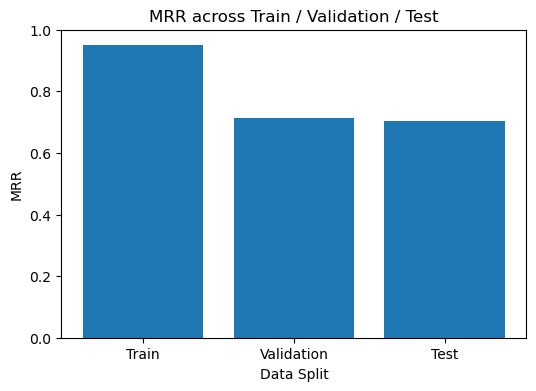

In [560]:
results = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'MRR': [mrr_train, mrr_val, mrr_test]
})

plt.figure(figsize=(6,4))
plt.bar(results['Split'], results['MRR'])
plt.ylim(0, 1)
plt.title('MRR across Train / Validation / Test')
plt.ylabel('MRR')
plt.xlabel('Data Split')
plt.show()

In [561]:
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_mrrs = []
val_mrrs = []
train_p5 = []
val_p5 = []

unique_cvs = cv_train.unique()
for frac in train_sizes:
    n_cvs = int(len(unique_cvs) * frac)
    selected_cvs = unique_cvs[:n_cvs]
    mask = cv_train.isin(selected_cvs)

    X_sub = X_train[mask]
    y_sub = y_train[mask]
    cv_sub = cv_train[mask]

    model = LogisticRegression(max_iter=1000,class_weight='balanced')
    model.fit(X_sub, y_sub)

    train_rank = rank(X_sub, y_sub, cv_sub,model)
    val_rank = rank(X_val, y_val, cv_val,model)

    train_p5.append(precision_at_k(train_rank, k=5))
    val_p5.append(precision_at_k(val_rank, k=5))

    train_mrrs.append(mean_reciprocal_rank(train_rank))
    val_mrrs.append(mean_reciprocal_rank(val_rank))


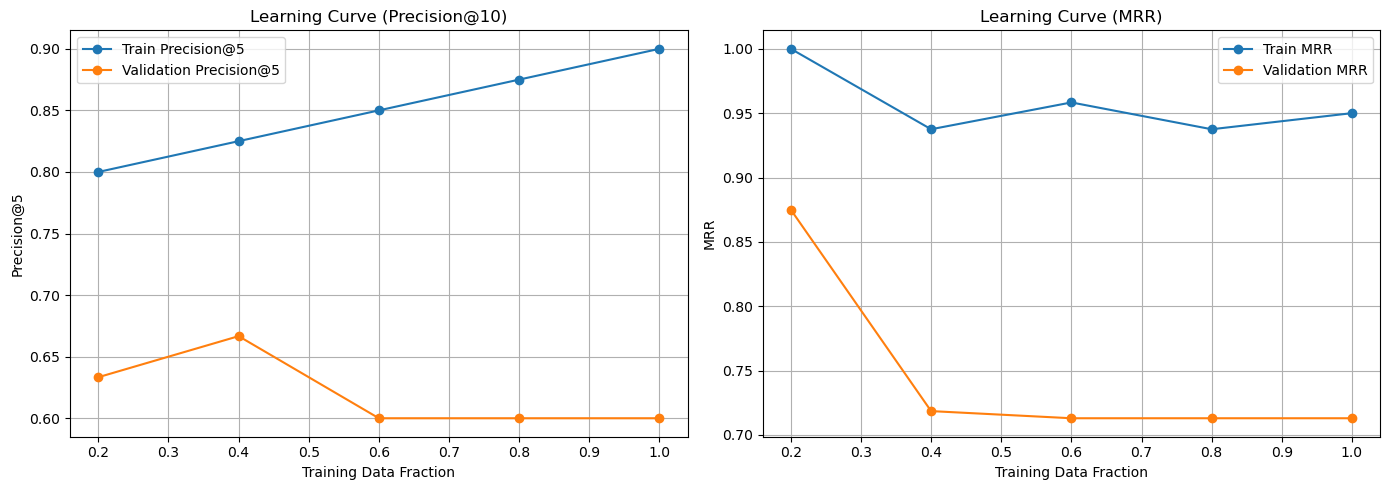

In [562]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- Plot 1: Precision@10 --------
axes[0].plot(train_sizes, train_p5, marker='o', label='Train Precision@5')
axes[0].plot(train_sizes, val_p5, marker='o', label='Validation Precision@5')

axes[0].set_xlabel("Training Data Fraction")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Learning Curve (Precision@10)")
axes[0].legend()
axes[0].grid(True)

# -------- Plot 2: MRR --------
axes[1].plot(train_sizes, train_mrrs, marker='o', label='Train MRR')
axes[1].plot(train_sizes, val_mrrs, marker='o', label='Validation MRR')

axes[1].set_xlabel("Training Data Fraction")
axes[1].set_ylabel("MRR")
axes[1].set_title("Learning Curve (MRR)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Precision@10 (left graph):
## When the training data was very small, the model looked perfect because it was basically memorizing the few CVs it saw. As more data was added, training performance dropped to a more realistic level, which is normal.
# The strange part is that validation performance is higher than training at the end. This means the validation CVs are easier than the training ones, or the model generalizes better on them.

## MRR (right graph):
## The zig-zag shape shows that the dataset is very small. Each time you add a new CV, it can strongly affect the result.
## If the new CV is hard or unusual, MRR drops. If it is easy, MRR goes up again.

## Overall:
## The behavior of both graphs mainly comes from having a small dataset. The model is not unstable by itself; the data size and difficulty are driving these changes.

In [564]:
# c small --> alpha large -->reduce overfitting
C_values = [0.0001,0.001,0.03,0.01,0.05,100]

results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        penalty = 'l2',
        class_weight='balanced'
    )

    model.fit(X_train, y_train)

    val_rank = rank(X_val, y_val, cv_val,model)
    val_mrr = mean_reciprocal_rank(val_rank)

    train_rank = rank(X_train, y_train, cv_train,model)
    train_mrr = mean_reciprocal_rank(train_rank)
    results.append({
        'C': C,
        'val_MRR': val_mrr,
        'train_MRR':train_mrr,
        'diff (train,val)' :train_mrr - val_mrr
    })

In [565]:
# with class_weight='balanced'
results_df = pd.DataFrame(results)
results_df

,C,val_MRR,train_MRR,"diff (train,val)"
0,0.0001,0.916667,0.916667,1.110223e-16
1,0.0010,1.000000,1.000000,0.000000e+00
2,0.0300,0.740741,0.975000,2.342593e-01
3,0.0100,0.746032,1.000000,2.539683e-01
4,0.0500,0.740741,0.975000,2.342593e-01
5,100.0000,0.712963,0.941667,2.287037e-01


In [566]:
C_values = [0.0001,0.001,0.03,0.01,0.05,100]

results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        penalty = 'l2'
    )

    model.fit(X_train, y_train)

    val_rank = rank(X_val, y_val, cv_val,model)
    val_mrr = mean_reciprocal_rank(val_rank)

    train_rank = rank(X_train, y_train, cv_train,model)
    train_mrr = mean_reciprocal_rank(train_rank)
    results.append({
        'C': C,
        'val_MRR': val_mrr,
        'train_MRR':train_mrr,
        'diff (train,val)' :train_mrr - val_mrr
    })

In [567]:
# without class_weight='balanced'
results_df = pd.DataFrame(results)
results_df

,C,val_MRR,train_MRR,"diff (train,val)"
0,0.0001,0.750000,0.860,0.110000
1,0.0010,1.000000,1.000,0.000000
2,0.0300,0.740741,0.975,0.234259
3,0.0100,0.763889,1.000,0.236111
4,0.0500,0.740741,0.975,0.234259
5,100.0000,0.712963,0.950,0.237037


In [568]:
penalties = ["l1", "l2"]
C = 100

results = []

for penalty in penalties:
    model = LogisticRegression(
        C=C,
        penalty=penalty,
        class_weight='balanced',
        solver = 'saga',
        max_iter=1000,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Validation
    val_rank = rank(X_val, y_val, cv_val, model)
    val_mrr = mean_reciprocal_rank(val_rank)

    # Train
    train_rank = rank(X_train, y_train, cv_train, model)
    train_mrr = mean_reciprocal_rank(train_rank)

    results.append({
        "C": C,
        "penalty": penalty,
        "val_MRR": val_mrr,
        "train_MRR": train_mrr,
        "diff (train-val)": train_mrr - val_mrr
    })

results

C:\Users\Zakaria\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Zakaria\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[{'C': 100,
  'penalty': 'l1',
  'val_MRR': 0.7129629629629629,
  'train_MRR': 0.95,
  'diff (train-val)': 0.23703703703703705},
 {'C': 100,
  'penalty': 'l2',
  'val_MRR': 0.7129629629629629,
  'train_MRR': 0.95,
  'diff (train-val)': 0.23703703703703705}]

## class_weight='balanced'

## Inclusion: Ensures the model recognizes rare job roles by giving them equal importance during training.

## Fairness: Prevents bias toward majority job categories, making recommendations more diverse and equitable.

# C = 100 --> alpha low 

## Generalization: Reduces model complexity to prevent it from "memorizing" the training data

## Stability: Bridged the gap between Train and Test

In [570]:
final_model = LogisticRegression(
    C=100,
    penalty='l2',
    max_iter=1000,
    class_weight='balanced'
)
final_model.fit(X_train, y_train)

LogisticRegression(C=100, class_weight='balanced', max_iter=1000)

In [571]:
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_mrrs = []
val_mrrs = []
train_p5 = []
val_p5 = []

unique_cvs = cv_train.unique()

for frac in train_sizes:
    n_cvs = int(len(unique_cvs) * frac)
    selected_cvs = unique_cvs[:n_cvs]

    mask = cv_train.isin(selected_cvs)

    X_sub = X_train[mask]
    y_sub = y_train[mask]
    cv_sub = cv_train[mask]

    final_model = LogisticRegression(C=100,max_iter=1000,
        penalty = 'l2',
        class_weight='balanced')

    final_model.fit(X_sub, y_sub)

    train_rank = rank(X_sub, y_sub, cv_sub,final_model)
    val_rank = rank(X_val, y_val, cv_val,final_model)

    train_p5.append(precision_at_k(train_rank, k=5))
    val_p5.append(precision_at_k(val_rank, k=5))

    train_mrrs.append(mean_reciprocal_rank(train_rank))
    val_mrrs.append(mean_reciprocal_rank(val_rank))


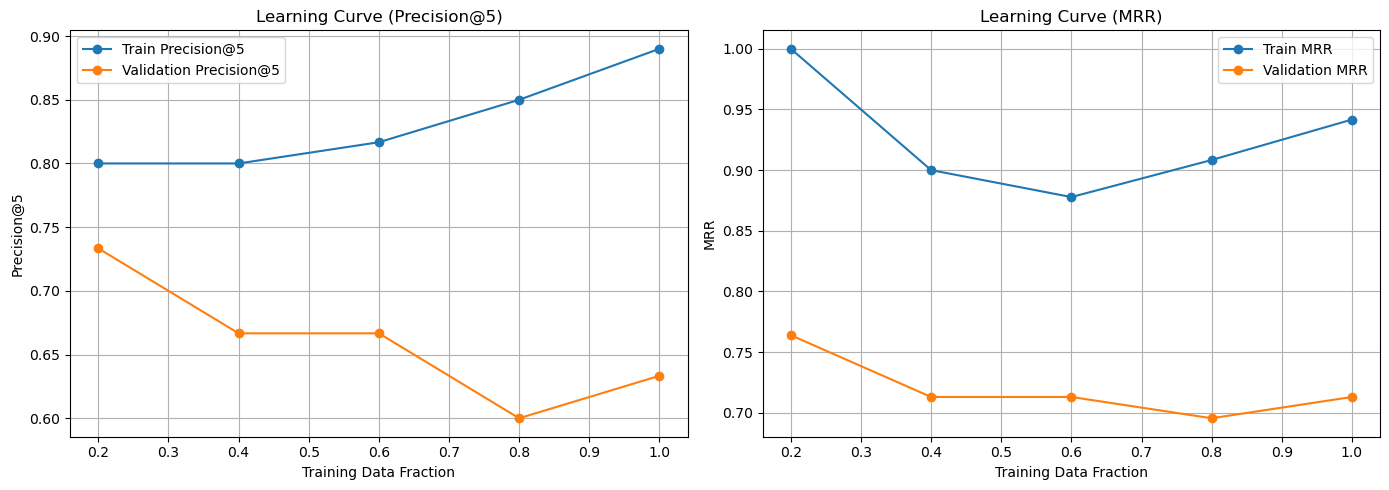

In [572]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- Plot 1: Precision@10 --------
axes[0].plot(train_sizes, train_p5, marker='o', label='Train Precision@5')
axes[0].plot(train_sizes, val_p5, marker='o', label='Validation Precision@5')

axes[0].set_xlabel("Training Data Fraction")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Learning Curve (Precision@5)")
axes[0].legend()
axes[0].grid(True)

# -------- Plot 2: MRR --------
axes[1].plot(train_sizes, train_mrrs, marker='o', label='Train MRR')
axes[1].plot(train_sizes, val_mrrs, marker='o', label='Validation MRR')

axes[1].set_xlabel("Training Data Fraction")
axes[1].set_ylabel("MRR")
axes[1].set_title("Learning Curve (MRR)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [573]:
mrr_v = mean_reciprocal_rank(rank(X_val,y_val,cv_val,final_model))
mrr_test = mean_reciprocal_rank(rank(X_test,y_test,cv_test,final_model))
mrr_train = mean_reciprocal_rank(rank(X_train,y_train,cv_train,final_model))

per_v = precision_at_k(rank(X_val,y_val,cv_val,final_model),k=10)
per_test = precision_at_k(rank(X_test,y_test,cv_test,final_model),k=10)
per_train = precision_at_k(rank(X_train,y_train,cv_train,final_model),k=10
                           )

print(f"val {mrr_v}, size:{X_val.shape[0]}")
print(f"test {mrr_test}, size:{X_test.shape[0]}")
print(f"train {mrr_train}, size:{X_train.shape[0]}")

print("-"*100)

print(f"per5 val {per_v}, size:{X_val.shape[0]}")
print(f"per5 test {per_test}, size:{X_test.shape[0]}")
print(f"per5 train {per_train}, size:{X_train.shape[0]}")

val 0.7129629629629629, size:1908
test 0.6947496947496946, size:1908
train 0.9416666666666667, size:6360
----------------------------------------------------------------------------------------------------
per5 val 0.6833333333333335, size:1908
per5 test 0.6666666666666666, size:1908
per5 train 0.8400000000000001, size:6360


C:\Users\Zakaria\AppData\Local\Temp\ipykernel_23652\4100603201.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


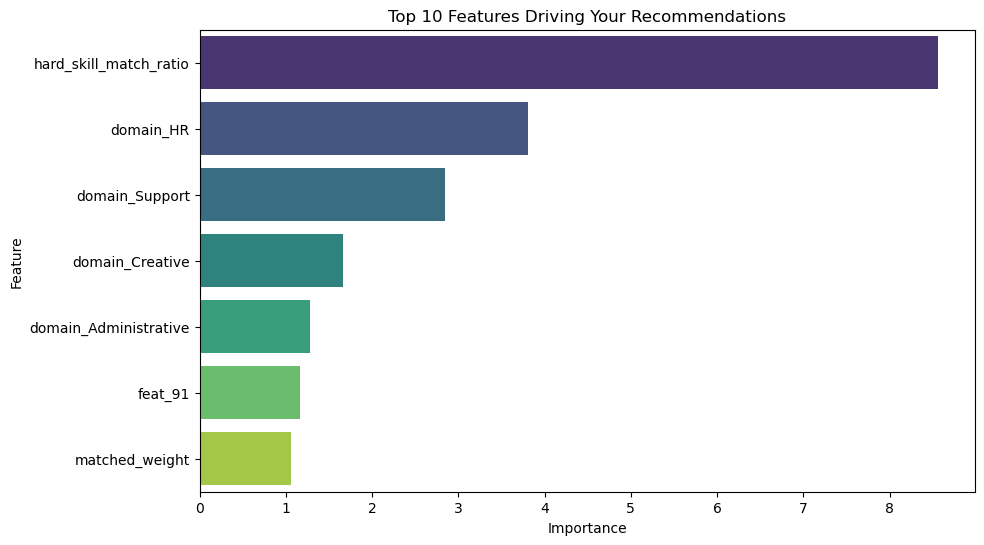

In [574]:

final_model = LogisticRegression(C=5, max_iter=1000, penalty='l2', class_weight='balanced')
final_model.fit(X_train, y_train)


feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.coef_[0]
})


feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(7)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 10 Features Driving Your Recommendations')
plt.show()
plt.show()

C:\Users\Zakaria\AppData\Local\Temp\ipykernel_23652\2090872550.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


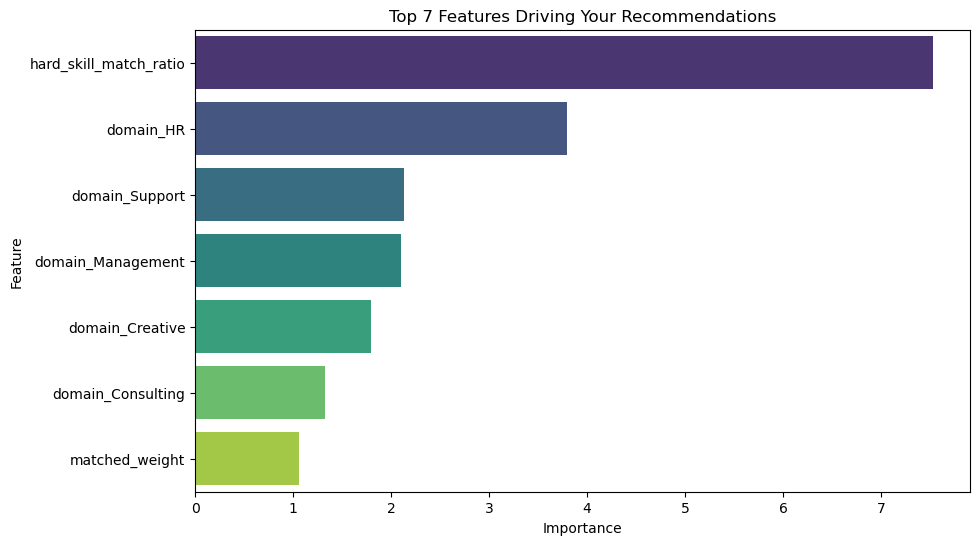

In [575]:
final_model = LogisticRegression(C=5, max_iter=1000, penalty='l2', class_weight='balanced')
final_model.fit(X_val, y_val)


feature_importance = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': final_model.coef_[0]
})


feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(7)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 7 Features Driving Your Recommendations')
plt.show()
plt.show()

In [576]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def calculate_per_group_metrics(df):
    group_metrics = []

    for cv_id, group in df.groupby('cv_id'):
        acc = accuracy_score(group['actual'], group['predicted'])
        f1 = f1_score(group['actual'], group['predicted'], zero_division=0)
        
 
        group_sorted = group.sort_values(by='score', ascending=False).reset_index(drop=True)
        hit_index = group_sorted[group_sorted['actual'] == 1].index
        mrr = 1.0 / (hit_index[0] + 1) if len(hit_index) > 0 else 0

        group_metrics.append({
            'cv_id': cv_id,
            'accuracy': acc,
            'f1_score': f1,
            'mrr': mrr
        })
    return pd.DataFrame(group_metrics)

def evaluate_set(X, y, cv_ids, model, set_name="Dataset"):
    # 1. Prediction
    scores = model.predict_proba(X)[:, 1]
    preds = model.predict(X)

    df_results = pd.DataFrame({
        'cv_id': cv_ids.values,
        'actual': y.values,
        'predicted': preds,
        'score': scores
    })


    metrics_df = calculate_per_group_metrics(df_results)
    

    print(f"\n{'='*10} {set_name} Results {'='*10}")
    print(f"Mean Accuracy: {metrics_df['accuracy'].mean():.4f}")
    print(f"Mean F1 Score: {metrics_df['f1_score'].mean():.4f}")
    print(f"Mean MRR:      {metrics_df['mrr'].mean():.4f}")
    
    return metrics_df, df_results



# 1. Train
train_metrics, train_res = evaluate_set(X_train, y_train, cv_train, final_model, "TRAIN")

# 2. Validation
val_metrics, val_res = evaluate_set(X_val, y_val, cv_val, final_model, "VALIDATION")

# 3. Test
test_metrics, test_res = evaluate_set(X_test, y_test, cv_test, final_model, "TEST")


========== TRAIN Results ==========
Mean Accuracy: 0.8547
Mean F1 Score: 0.6573
Mean MRR:      0.9125

========== VALIDATION Results ==========
Mean Accuracy: 0.9392
Mean F1 Score: 0.5958
Mean MRR:      0.7153

========== TEST Results ==========
Mean Accuracy: 0.8265
Mean F1 Score: 0.5155
Mean MRR:      0.7002
